(data_projection)=

# Mapping cells and transferring labels

Mapping is the fixed-reference alternative to merging datasets and rebuilding a joint graph.
This allows you to keep one reference atlas unchanged, place new query cells onto it, and transfer labels from reference neighbours.
The prepared mapping reference is also the reusable atlas: later queries use the same feature panel,
projection model, reference coordinates, and neighbour index.

It does three things in order:

1. Align the query features to the reference feature panel.
2. Project each query cell into the reference PCA space and find nearest reference neighbours.
3. Use those neighbours to transfer labels and score how much of the query landed on each reference cell.

It does not merge count matrices, retrain the reference graph, or move reference cells.
When sources must be analysed together in one store, start with [](dataset_merging.ipynb) and [](batch_correction.ipynb) instead.

In this tutorial, we will be mapping interferon-stimulated PBMCs onto a control PBMC reference from the same Kang study.
The shared author labels let us evaluate the result.

Mapping currently supports RNA queries. Keep the reference and query in separate stores;
the query store must be writable so CyteArc can save the mapping and transferred labels.

## 1. Open the reference and query

In [1]:
# Work with numeric arrays and cell masks.
import numpy as np

# Summarize the query populations in a labeled table.
import pandas as pd

# Open count stores and run CyteArc analyses.
import cytearc

# Give the reference and query plots descriptive labels.
from cytearc.plotting import CellField

# Keep routine logs and progress bars out of the results.
cytearc.configure_output(level="WARNING", progress=False)

# Connect to the public example-data repository.
repository = cytearc.cytebase.connect("cytearc_docs")

# Download the unstimulated reference cells.
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="cytearc_datasets",
    zarr=True,
)

# Open the reference count store.
ds_ctrl = cytearc.DataStore(
    f"{ctrl_path}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

# Inspect the opened store's cells and features.
ds_ctrl

DataStore has 8486 (8487) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_UMAP1', 'RNA_UMAP2', 
            'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 
            'RNA_percentRibo', 'cluster_labels'
   RNA assay has 35635 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells'

Started: 2026-10-08T11:03:25.700995Z | Wall time: 31.750 s

In [2]:
# Download the interferon-stimulated query cells.
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="cytearc_datasets",
    zarr=True,
)

# Open the query store where mapping results will be saved.
ds_stim = cytearc.DataStore(
    f"{stim_path}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

# Inspect the opened store's cells and features.
ds_stim

DataStore has 10111 (10111) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_UMAP1', 'RNA_UMAP2', 
            'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 
            'RNA_percentRibo', 'cluster_labels'
   RNA assay has 35635 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells'

Started: 2026-10-08T11:03:57.454852Z | Wall time: 10.588 s

First, look at the author labels in both datasets.

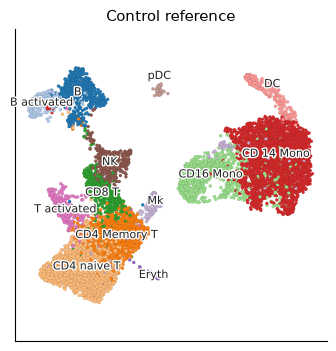

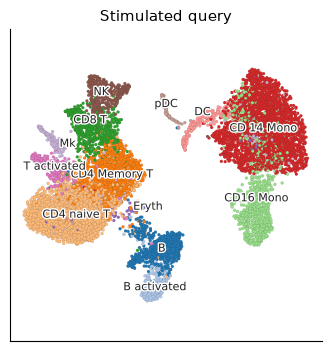

Started: 2026-10-08T11:04:08.046378Z | Wall time: 2.402 s

In [3]:
# Inspect the published labels in the control reference.
ds_ctrl.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=CellField("cluster_labels", label="Control reference"),
)

# Inspect the published labels in the stimulated query.
ds_stim.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=CellField("cluster_labels", label="Stimulated query"),
)

These UMAP layouts were fitted independently, so their coordinates are not comparable.
Mapping keeps the control layout fixed and reports where query weight lands on reference cells.
The shared label vocabulary is what we use for evaluation.

## 2. Prepare a labelled, reusable reference

The control store already contains an analysis named `docs_default`. Use its neighbours to
prepare a reference that later queries can share.

In [4]:
# Open the saved analysis and its exact results.
run = ds_ctrl.pipeline.open(label="docs_default")

# Keep the reference UMAP fixed for mapping-score plots.
reference_layout = run["umap"]

# Prepare a reusable reference from the saved neighbors.
reference_ref = ds_ctrl.mapping.build_reference(run["neighbors"])

# Load the saved reference model.
reference = ds_ctrl.mapping.load_reference(reference_ref)

# Inspect the reference saved for future query datasets.
reference_ref

ArtifactRef(assay='RNA', kind='mapping_reference', artifact_id='659997090e3b...')

Started: 2026-10-08T11:04:10.451886Z | Wall time: 0.989 s

The completed `MappingReference` is immutable.
Its `feature_selection` field pins the exact reference feature artifact rather than a metadata key.
Its feature order, scaling, PCA loadings, neighbour index, and selected cells stay fixed in the reference datastore.
`reference_layout` is the immutable UMAP from the same run and is used only to show where query
weight landed.
The mapping reference does not contain that layout or the reference labels. Label transfer
freezes the labels it uses when it runs (section 5).

## 3. Map the query

`mapping.run` runs on the writable query datastore.
It aligns query features to the reference panel, applies the reference normalization and scaling, projects into the reference PCA space, and stores the nearest neighbours.
Query cells are never inserted into the reference index.

We map the cells of the query's own pipeline run, so that the results can be drawn on that run's
UMAP later. The default mapping keeps the three nearest reference neighbours for each query cell.

In [5]:
# Open the saved analysis of the query cells.
query_run = ds_stim.pipeline.open(label="docs_default")

# Keep the query UMAP for displaying transferred labels.
query_layout = query_run["umap"]

# Map the selected query cells onto the fixed reference.
mapping_ref = ds_stim.mapping.run(reference, query_run['analysis_cell_selection'])

# Inspect the saved query-mapping reference.
mapping_ref

ArtifactRef(assay='RNA', kind='projection', artifact_id='53137ba8e808...')

Started: 2026-10-08T11:04:11.445413Z | Wall time: 4.093 s

Reload the saved mapping to inspect its diagnostics:

In [6]:
# Load the saved mapping and its diagnostics.
mapping = ds_stim.mapping.load_result(mapping_ref, reference=reference)

# Inspect feature coverage and query mapping diagnostics.
mapping.diagnostics

{'featureCoverage': 1.0,
 'queryBatchCount': 1,
 'algorithmVariant': 'scaled_pca',
 'uninformativeCellCount': 0,
 'queryScaledDispersion': 1.329895474385472}

Started: 2026-10-08T11:04:15.542656Z | Wall time: 0.143 s

By default, an absent query feature is filled with the reference mean, which becomes zero after
reference scaling. Check `featureCoverage` in the diagnostics before interpreting transferred labels.

Cells with no counts in the measured reference features are flagged as uninformative.
They cannot provide evidence for a transferred label.

## 4. Where did the query land?

A mapping score tells you which reference cells received neighbour weight from the query. This can be plotted on the reference UMAP.
Since one panel for the whole query becomes hard to read due to the weight being spread across many cells,
we can split by a few known query populations to see whether each population lands on the matching reference region.
The author labels of the mapped cells are read in the order of the run's cells.

In [7]:
# Find the query cell rows included in the saved analysis.
mapped_rows = np.flatnonzero(query_run.cells.fetch_all("I"))

# Read the published labels in mapped-cell order.
query_labels = np.asarray(ds_stim.cells.fetch_all("cluster_labels"))[mapped_rows]

# Use text labels consistently when forming plot groups.
query_labels = query_labels.astype(str)

# Choose a few known populations for separate mapping-score panels.
focus = {"CD 14 Mono", "CD4 Memory T", "CD4 naive T", "NK"}

# Keep the selected populations and group the remaining labels as other.
score_groups = np.array(
    [label if label in focus else "other" for label in query_labels],
    dtype=object,
)

# Count cells in each mapping-score group.
pd.Series(score_groups, name="query population").value_counts().to_frame("cells")

,cells
query population,
other,3462
CD 14 Mono,2532
CD4 naive T,2390
CD4 Memory T,1297
NK,430


Started: 2026-10-08T11:04:15.688493Z | Wall time: 0.157 s

Show where each query population contributes weight on the reference map:

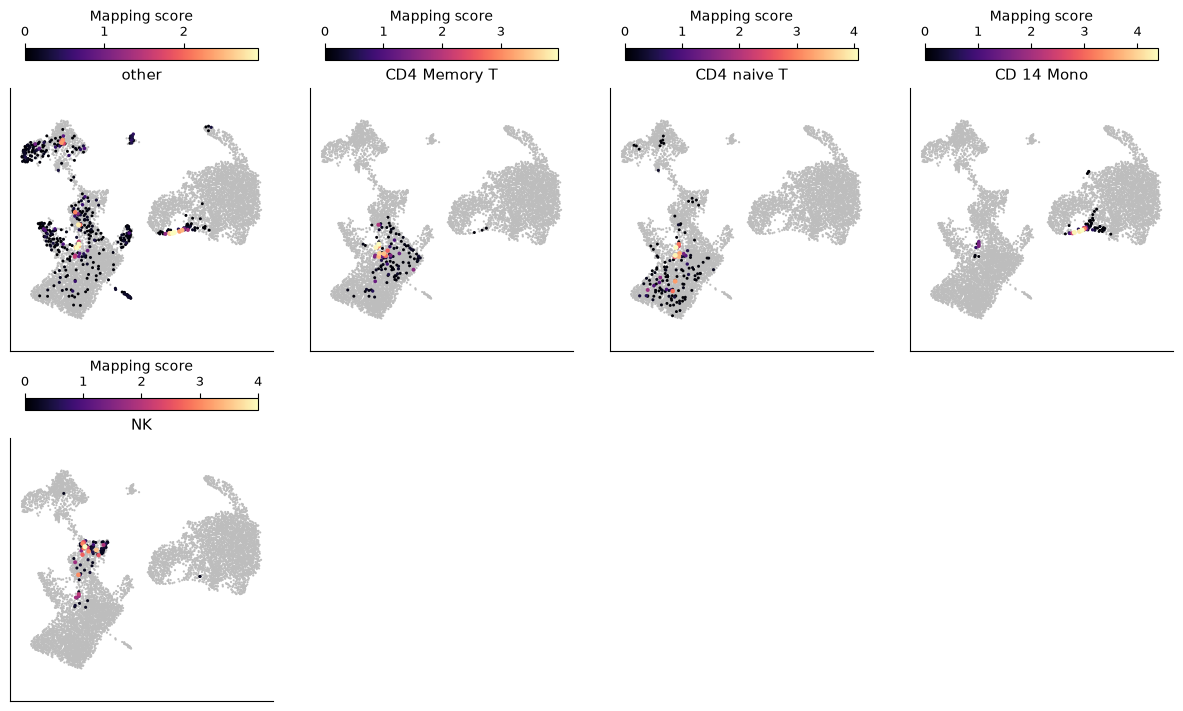

Started: 2026-10-08T11:04:15.848632Z | Wall time: 1.057 s

In [8]:
# Show where each query group contributes weight on the reference.
ds_stim.plots.mapping_score(
    mapping_ref,
    reference=reference,
    layout=reference_layout,
    target_groups=score_groups,
    size_by_score=True,
    figsize=(12, 7),
)

Each panel here shows grey points which received no weight from that query group.
Coloured points are the reference cells that are neighbours to the cells in the query group; point size scales with score so sparse hits stay visible.
A useful mapping of the query group will light up the matching reference population.
Alternatively, concentration in an unrelated pocket suggests a domain shift or a feature-alignment problem.

## 5. Transfer labels and inspect evidence

Each reference neighbour votes for its annotation with a weight derived from its distance to
the query cell. Label transfer sums these weights for each label. By default, a unique winning
label needs at least half of the total neighbour weight. Neighbours without labels contribute
to that total but cannot support a label.
Otherwise the cell abstains and gets no label.
A high vote fraction only means the neighbours agreed.
It is not a calibrated probability that the label is biologically correct.

`mapping.transfer_labels` saves the result as an immutable `label_transfer` artifact in the query
datastore and returns its reference. It first freezes the reference labels it reads into the query
datastore, so later edits to the reference annotations cannot change this result.

In [9]:
# Transfer reference labels with the default abstention threshold.
transfer_ref = ds_stim.mapping.transfer_labels(
    mapping_ref,
    reference=reference,
    reference_labels="cluster_labels",
)

# Load the transferred labels and their supporting evidence.
transfer = ds_stim.mapping.load_label_transfer(transfer_ref)

# Count cells in each reported category.
transfer.labels.notna().value_counts().rename(
    index={True: "labelled", False: "abstained"}
).rename("query cells")

label
labelled     9475
abstained     636
Name: query cells, dtype: int64

Started: 2026-10-08T11:04:16.909568Z | Wall time: 0.650 s

An abstained cell has a missing label, and the `abstentionReason` column of `transfer.evidence`
says why:

- `below_threshold`: the winning vote fraction is below `threshold_fraction`
- `tied_vote`: two labels received the same neighbour weight
- `uninformative_cell`: the cell has no counts in any reference feature that the query measured
- `no_labeled_neighbors`: no neighbour has a usable reference label
- `beyond_max_distance`: the nearest reference neighbour is farther than `max_distance`, when one is set

Uninformative cells also add nothing to mapping scores.

In [10]:
# Count cells in each reported category.
transfer.evidence["abstentionReason"].value_counts()

abstentionReason
below_threshold    636
Name: count, dtype: int64

Started: 2026-10-08T11:04:17.564840Z | Wall time: 0.009 s

Plot the transferred labels on the query UMAP.
A label artifact colours an embedding directly, so nothing is written into the query cell metadata.
Abstained cells are drawn as missing, which shows the geography of abstention.

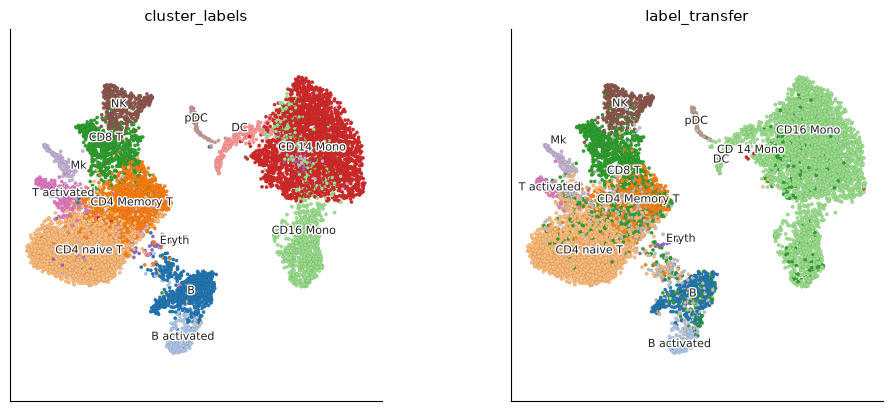

Started: 2026-10-08T11:04:17.578093Z | Wall time: 1.326 s

In [11]:
# Compare published and transferred labels on the query UMAP.
ds_stim.plots.embedding(
    layout=query_layout,
    color_by=["cluster_labels", transfer_ref],
    figsize=(10, 4),
)

`mapping_evidence` plots the evidence saved with the transfer:

- `voteFraction`: how much neighbour weight supports the winning label
- `topTwoMargin`: how far the winner sits above the runner-up
- `referenceDistancePercentile`: how unusual the query cell is relative to reference neighbour distances

`voteFraction` is compared with `threshold_fraction` when labels are assigned. The margin and
distance percentile are diagnostics; they do not add abstention rules. Drawing this plot does
not change the saved labels.

To also abstain by nearest-neighbour distance, pass `max_distance` to `mapping.transfer_labels`. That saves a second
transfer and leaves this one unchanged.

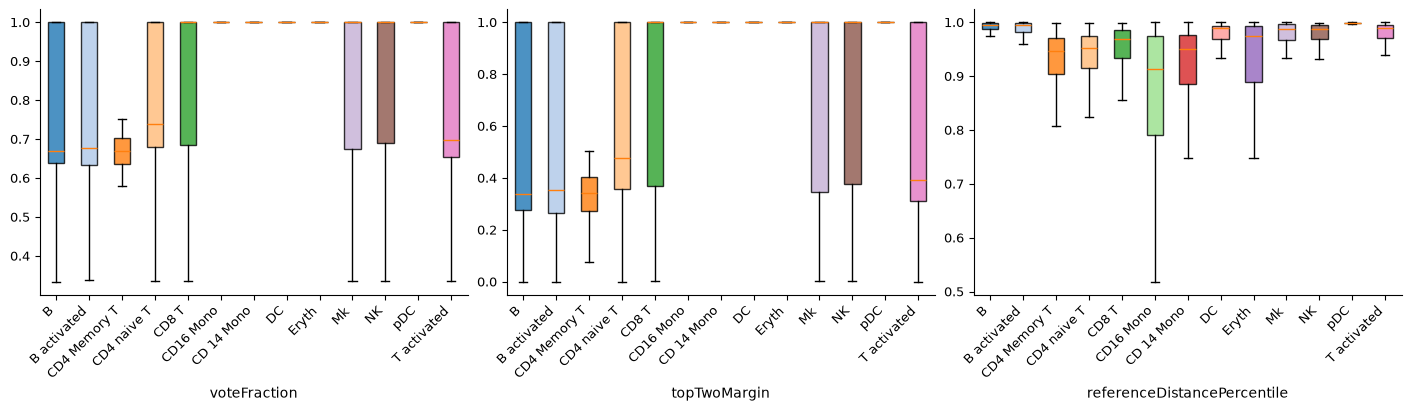

Started: 2026-10-08T11:04:18.909495Z | Wall time: 0.843 s

In [12]:
# Inspect the evidence supporting transferred labels.
ds_stim.plots.mapping_evidence(
    transfer_ref,
    target_groups=query_labels,
    metrics=("voteFraction", "topTwoMargin", "referenceDistancePercentile"),
    kind="box",
    figsize=(14, 4),
)

Because this query dataset also carries original author labels, we can compare these known labels
with the transferred labels.

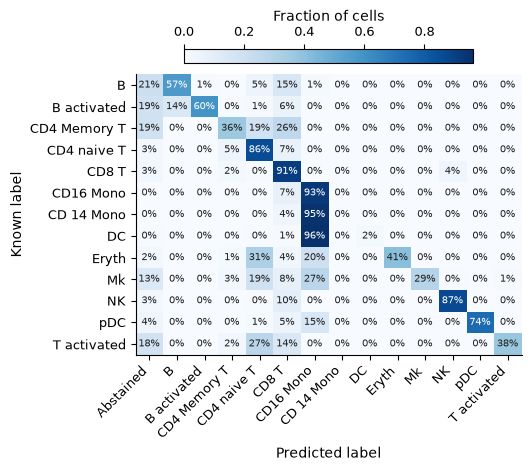

Started: 2026-10-08T11:04:19.756054Z | Wall time: 1.493 s

In [13]:
# Compare transferred labels with the known query labels.
ds_stim.plots.mapping_confusion(
    transfer_ref,
    known_labels=query_labels,
    normalize="true",
)

Cells where the known and predicted labels match show recall within each known query label.
Blocks between different labels show systematic swaps.
The `Abstained` column holds the cells that did not receive a transferred label.
Pay particular attention to the monocyte rows. Stimulation can change expression enough that a
query population maps to another reference label. Inspect such swaps before accepting the labels.

Because known labels are available, `mapping_calibration` shows how label accuracy trades off against retained coverage as the vote threshold rises.
It applies each threshold to the candidate labels saved with the transfer, so nothing is recomputed.
Coverage is the share of cells with a known label that a threshold keeps. Cells that abstained
without evidence stay in that share and are never kept, so the curve counts the same cells as the
confusion matrix.
The red marker is the transfer's own `threshold_fraction`.
Higher thresholds keep fewer cells. Use this curve to check whether the retained labels are
also more accurate in this dataset.

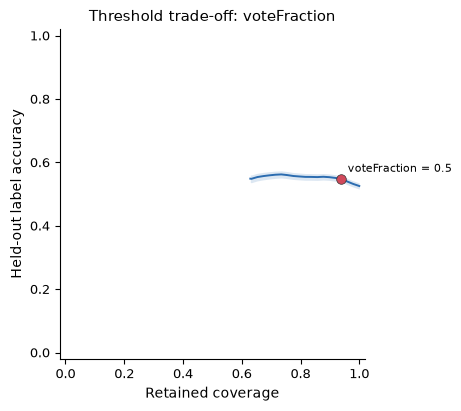

Started: 2026-10-08T11:04:21.252959Z | Wall time: 0.335 s

In [14]:
# Compare label accuracy and retained coverage across thresholds.
ds_stim.plots.mapping_calibration(transfer_ref, known_labels=query_labels)

## 6. Choose stricter settings when needed

The first pass used the defaults. If too many uncertain labels remain, raise
`threshold_fraction` in `mapping.transfer_labels`. For example, `threshold_fraction=0.6` requires
60% of the neighbour weight to support the winning label. It saves a separate transfer,
so you can compare it with the first one. Use the confusion matrix and calibration curve to
judge the tradeoff between coverage and agreement with known labels.

You can also change `save_k` in `mapping.run` to consider more reference neighbours.
This creates a new mapping and can change which populations receive weight. More neighbours
are not automatically better, especially near boundaries between cell types.

For missing features, `missing_feature_policy="error"` requires complete overlap;
`"zero"` fills an absent feature with a normalized zero. The default, `"reference_mean"`,
is the path used above.

`mapping.diagnostics["queryScaledDispersion"]` is calculated from comparing query spread with the reference after scaling.
Only informative query cells and the reference features the query measured enter it, so the missing-feature fill does not change it.
Values near 1 mean a similar average scaled distance from the reference centre;
they do not establish matching cell types.
Values much below 1 mean the query is compressed toward the centre of the reference cloud and neighbour labels become less trustworthy.
RNA normalization renormalizes counts over the selected features by default (`renormalize_subset=True`).
With that setting and `featureCoverage` below 1, query cells are renormalized over fewer features than the reference used, so the value is not comparable with 1.

A query cell is uninformative when its raw counts are zero in every reference feature that the query measured.
Such a cell carries no query evidence. It is flagged in `mapping.uninformative` and counted by `mapping.diagnostics["uninformativeCellCount"]`.

This example uses a plain PCA reference. Use a Harmony-backed Symphony reference only when
both reference and query have defensible technical-batch metadata. Stimulation and disease
are biological conditions, so they should not be substituted for technical batches.

(reference-atlas-mapping)=
(reference_atlas_mapping)=

## 7. Reuse the reference and saved labels

A reusable atlas is the fixed `MappingReference` prepared in this tutorial, together with its
reference datastore and separately retained layout artifact.

In a later session, retain the mapping-reference, projection, and label-transfer artifact refs,
reopen both stores, and reload the exact results. A saved transfer loads from the query datastore
alone:

In [15]:
# Load the saved reference model.
reference = ds_ctrl.mapping.load_reference(reference_ref)

# Reload the exact mapping without recomputing it.
reloaded_mapping = ds_stim.mapping.load_result(mapping_ref, reference=reference)

# Reload the saved labels from the query store.
reloaded_transfer = ds_stim.mapping.load_label_transfer(transfer_ref)

# Check the reloaded cell count, correction, label source, and threshold.
(
    reloaded_mapping.n_cells,
    reloaded_mapping.correction_method,
    reloaded_transfer.reference_label_source,
    reloaded_transfer.threshold_fraction,
)

(10111, 'none', 'cluster_labels', 0.5)

Started: 2026-10-08T11:04:21.591754Z | Wall time: 0.555 s

For repeated use, reopen the prepared reference datastore read-only and run each mapping in a
separate writable query datastore. If query counts come from a read-only source or the same physical
store used to prepare the reference, use `mount_datastore` to create that separate query store.

Reference labels are frozen when labels are transferred. `mapping.transfer_labels` copies the labels it
reads into the query datastore as a `reference_labels` artifact, which records their source column
or artifact and a fingerprint of their values. Transferring again with unchanged labels and settings
reuses the saved transfer. After the reference annotations change, the same call saves a new
transfer next to the old one, and the old transfer keeps its labels. Reference labels can also be a
cell-label artifact of the reference datastore, such as a clustering or a `smart_label` artifact
returned by `ds.clusters.relabel_by_overlap`. Retain the layout artifact separately when mapping scores must be displayed on the
original reference UMAP.

The lineage of a transfer follows its inputs into the reference datastore: from the query labels
through the threshold, the frozen reference labels, and the projection, to the reference model and
the cells it was built from.

In [16]:
# Display the saved result and its upstream inputs.
ds_stim.artifacts.lineage(transfer_ref, references=reference)

```mermaid
flowchart LR
    artifact0["external c307164da4e5 / RNA / metadata_snapshot | snapshot_run_metadata | 28261c12ec7a"]
    artifact1["external c307164da4e5 / datastore / cell_selection | snapshot_pipeline_input_selection | 4394c7c59fc4"]
    artifact2["external c307164da4e5 / datastore / metadata_snapshot | snapshot_run_metadata | b73aa20b65dd"]
    artifact3["external c307164da4e5 / datastore / cell_selection | filter_pipeline_cells | 0d07e87eadd6"]
    artifact4["external c307164da4e5 / RNA / feature_summary | summarize_rna_features | ec2f31f3e6fd"]
    artifact5["external c307164da4e5 / RNA / feature_selection | select_hvgs | 40784012baf4"]
    artifact6["external c307164da4e5 / RNA / normalized | run_normalization | da055e818081"]
    artifact7["external c307164da4e5 / RNA / feature_scaling | calculate_feature_scaling | 294432844dea"]
    artifact8["external c307164da4e5 / RNA / reduction | run_pca | 1745ff8dbd2f"]
    artifact9["external c307164da4e5 / RNA / ann_index | build_ann_index | 75230eed7c0c"]
    artifact10["external c307164da4e5 / RNA / neighbors | query_neighbors | f3b370b689a3"]
    artifact11["external c307164da4e5 / RNA / mapping_reference | build_mapping_reference | 659997090e3b"]
    artifact12["RNA / feature_selection | create_all_features | 0b409eb725f1"]
    artifact13["RNA / feature_selection | select_mapping_overlap | 5e8364cb5c65"]
    artifact14["datastore / cell_selection | snapshot_pipeline_input_selection | 0b2d53182037"]
    artifact15["datastore / metadata_snapshot | snapshot_run_metadata | 6395b56bfd71"]
    artifact16["datastore / cell_selection | filter_pipeline_cells | 3da9d3a1deac"]
    artifact17["RNA / projection | map_query | 53137ba8e808"]
    artifact18["datastore / reference_labels | freeze_reference_labels | dc3258ca7a44"]
    artifact19["RNA / label_transfer | transfer_labels | 7c8cdba73b8d | outputs: output"]
    artifact8 -->|"coordinates"| artifact10
    artifact9 -->|"ann_index"| artifact10
    artifact10 -->|"neighbors"| artifact11
    artifact3 -->|"cell_selection"| artifact11
    artifact5 -->|"feature_selection"| artifact11
    artifact8 -->|"reduction"| artifact11
    artifact9 -->|"ann_index"| artifact11
    artifact11 -->|"mapping_reference"| artifact13
    artifact12 -->|"all_features"| artifact13
    artifact14 -->|"input_cell_selection"| artifact16
    artifact15 -->|"cell_snapshot"| artifact16
    artifact11 -->|"mapping_reference"| artifact17
    artifact13 -->|"feature_selection"| artifact17
    artifact16 -->|"cell_selection"| artifact17
    artifact11 -->|"mapping_reference"| artifact18
    artifact16 -->|"cell_selection"| artifact19
    artifact17 -->|"projection"| artifact19
    artifact18 -->|"reference_labels"| artifact19
    artifact1 -->|"input_cell_selection"| artifact3
    artifact2 -->|"cell_snapshot"| artifact3
    artifact3 -->|"cell_selection"| artifact4
    artifact0 -->|"feature_snapshot"| artifact5
    artifact4 -->|"feature_summary"| artifact5
    artifact3 -->|"cell_selection"| artifact6
    artifact5 -->|"feature_selection"| artifact6
    artifact6 -->|"normalized"| artifact7
    artifact3 -->|"pca_cell_selection"| artifact8
    artifact6 -->|"normalized"| artifact8
    artifact7 -->|"feature_scaling"| artifact8
    artifact8 -->|"coordinates"| artifact9
```

### Artifact details

#### external c307164da4e5 / RNA / metadata_snapshot / 28261c12ec7a
- Status: `complete`
- Dataset fingerprint: `c307164da4e57100432d43a4e66f79606a6782be6d8b9dad97967da566e8ae61`
- Path: `RNA/artifacts/metadata_snapshot/28261c12ec7ac8448bcc648a0bdfc5b9e45de1e9db93c68e1681f16236be041d`
- Operation: `snapshot_run_metadata`
- Parameters: `assay="RNA"; axis="feature"; ordered_columns=["names"]`
- Other inputs: `column_fingerprints={"names":"7afff42cd629478314c7b959eea49de9b4adf3c446892d22f0ec89faa1428147"}; ordered_row_ids_fingerprint="3c72c553a3826cdced62264a7508f291fbc63b8d0025d9037faf21ba83e8a701"`

#### external c307164da4e5 / datastore / cell_selection / 4394c7c59fc4
- Status: `complete`
- Dataset fingerprint: `c307164da4e57100432d43a4e66f79606a6782be6d8b9dad97967da566e8ae61`
- Path: `artifacts/cell_selection/4394c7c59fc442c84c9be98036d4db712193fbd9c4943fd3632974491f84bf95`
- Operation: `snapshot_pipeline_input_selection`
- Parameters: `assay="RNA"`
- Execution options: `source_column="I"`
- Other inputs: `ordered_row_ids_fingerprint="4149f42b09e1ccd771fbed7d6a25fd912d8458dfa632a195683a9f81d9640fab"; values_fingerprint="b8d616fc8a463b7dfa21988fc4b73608cf86e8c18b49c29067e4246b4fa332ac"`

#### external c307164da4e5 / datastore / metadata_snapshot / b73aa20b65dd
- Status: `complete`
- Dataset fingerprint: `c307164da4e57100432d43a4e66f79606a6782be6d8b9dad97967da566e8ae61`
- Path: `artifacts/metadata_snapshot/b73aa20b65dd737f05fe4665f10b3830bbc6ba8fe393cecd2bdaaa3e152834c9`
- Operation: `snapshot_run_metadata`
- Parameters: `assay=null; axis="cell"; ordered_columns=["names","RNA_nCounts","RNA_nFeatures"]`
- Other inputs: `column_fingerprints={"RNA_nCounts":"8c4bba8587b2152921d993bd8e3e7a6c968cb60f5eb1d1ea7bd675c5a4e61b33","RNA_nFeatures":"f833e79b7c5bf6fa903a66649c756f985f752b0ca52e63fd7b966f2b50...; ordered_row_ids_fingerprint="4149f42b09e1ccd771fbed7d6a25fd912d8458dfa632a195683a9f81d9640fab"`

#### external c307164da4e5 / datastore / cell_selection / 0d07e87eadd6
- Status: `complete`
- Dataset fingerprint: `c307164da4e57100432d43a4e66f79606a6782be6d8b9dad97967da566e8ae61`
- Path: `artifacts/cell_selection/0d07e87eadd67e94b492ad8b997b6a9ee4433e3e58a7ed8c2cf02721633b3d0c`
- Operation: `filter_pipeline_cells`
- Parameters: `attrs=["RNA_nCounts","RNA_nFeatures"]; enabled=true; highs=[15000,4000]; keepBounds=false; lows=[500,200]; method="manual"`
- Execution options: `source_column="I"`
- Other inputs: `ordered_row_ids_fingerprint="4149f42b09e1ccd771fbed7d6a25fd912d8458dfa632a195683a9f81d9640fab"; values_fingerprint="1e44bf84df160b4519a76b6de9d4206eb57e2b74eb9980f598da1e9364d91f36"`

#### external c307164da4e5 / RNA / feature_summary / ec2f31f3e6fd
- Status: `complete`
- Dataset fingerprint: `c307164da4e57100432d43a4e66f79606a6782be6d8b9dad97967da566e8ae61`
- Path: `RNA/artifacts/feature_summary/ec2f31f3e6fdefaca3ae3d85d9cce4a06dbcccfd8207952bce3b359c4688392d`
- Operation: `summarize_rna_features`
- Parameters: `normalization_method={"module":"cytearc.assay","qualname":"norm_lib_size"}; size_factor=1000`
- Execution options: `nthreads=2`
- Other inputs: `dataset_fingerprint="c307164da4e57100432d43a4e66f79606a6782be6d8b9dad97967da566e8ae61"`

#### external c307164da4e5 / RNA / feature_selection / 40784012baf4
- Status: `complete`
- Dataset fingerprint: `c307164da4e57100432d43a4e66f79606a6782be6d8b9dad97967da566e8ae61`
- Path: `RNA/artifacts/feature_selection/40784012baf4c7a0f1046db430a83bdcbe1e93328b03719b978947a4e62e1537`
- Operation: `select_hvgs`
- Parameters: `bin_strategy="adaptive"; blacklist="^MT-|^RPS|^RPL|^MRPS|^MRPL|^CCN|^HLA-|^H2-|^HIST|^XIST$|^DDX3Y$|^USP9Y$|^EIF1AY$|^KDM5D$|^SRY$|^ZFY$|^UTY$|^TMSB4Y$|^NLGN4Y$"; blacklist_fingerprint="a7426093c043b0d039089234ea2595ca08aef122ace380a570ecc33df728375c"; keep_bounds=false; lowess_frac=0.1; max_cells=8466; max_mean={"special_float":"inf"}; max_var={"special_float":"inf"}; min_cells=20; min_mean={"special_float":"-inf"}; min_var={"special_float":"-inf"}; n_bins=200; ... 3 more`
- Execution options: `invalidate_cache=false; nthreads=2; plot_kwargs={}; show_plot=false`

#### external c307164da4e5 / RNA / normalized / da055e818081
- Status: `complete`
- Dataset fingerprint: `c307164da4e57100432d43a4e66f79606a6782be6d8b9dad97967da566e8ae61`
- Path: `RNA/artifacts/normalized/da055e818081c278077fcd29172fca0d8352f89140fb5f0ba80e383c210f4bba`
- Operation: `run_normalization`
- Parameters: `log_transform=true; normalization_method={"external_hook":true,"module":"cytearc.assay","qualname":"norm_lib_size"}; renormalize_subset=true; size_factor=1000.0`
- Execution options: `invalidate_cache=false`
- Other inputs: `dataset_fingerprint="c307164da4e57100432d43a4e66f79606a6782be6d8b9dad97967da566e8ae61"`

#### external c307164da4e5 / RNA / feature_scaling / 294432844dea
- Status: `complete`
- Dataset fingerprint: `c307164da4e57100432d43a4e66f79606a6782be6d8b9dad97967da566e8ae61`
- Path: `RNA/artifacts/feature_scaling/294432844dea0bd293bb5804d673ff8c048322e03ad81fa1575c9d4ab3937311`
- Operation: `calculate_feature_scaling`
- Parameters: `enabled=true`
- Execution options: `batch_size=8486; invalidate_cache=false; local_cache="auto"`

#### external c307164da4e5 / RNA / reduction / 1745ff8dbd2f
- Status: `complete`
- Dataset fingerprint: `c307164da4e57100432d43a4e66f79606a6782be6d8b9dad97967da566e8ae61`
- Path: `RNA/artifacts/reduction/1745ff8dbd2faffb74f94b0caffc444e476ce4379bfdcb8f706b80c8a877092b`
- Operation: `run_pca`
- Parameters: `dims=25; feat_scaling=true`
- Execution options: `batch_size=8486; invalidate_cache=false; local_cache="auto"; show_elbow_plot=false`

#### external c307164da4e5 / RNA / ann_index / 75230eed7c0c
- Status: `complete`
- Dataset fingerprint: `c307164da4e57100432d43a4e66f79606a6782be6d8b9dad97967da566e8ae61`
- Path: `RNA/artifacts/ann_index/75230eed7c0c30d4f4d69fe6726bd0d573c1dab129c43c86acf1119705164ac3`
- Operation: `build_ann_index`
- Parameters: `ann_ef=50; ann_efc=50; ann_m=48; ann_metric="l2"; ann_parallel=false; parallel_threads=null; rand_state=4466`
- Execution options: `batch_size=8486; invalidate_cache=false; nthreads=1`

#### external c307164da4e5 / RNA / neighbors / f3b370b689a3
- Status: `complete`
- Dataset fingerprint: `c307164da4e57100432d43a4e66f79606a6782be6d8b9dad97967da566e8ae61`
- Path: `RNA/artifacts/neighbors/f3b370b689a3a23ad75882297d9ea4b030b2130c5ed932579b6d1eea586d3a1c`
- Operation: `query_neighbors`
- Parameters: `distance_metric="l2"; k=21`
- Execution options: `batch_size=8486; invalidate_cache=false; nthreads=1`

#### external c307164da4e5 / RNA / mapping_reference / 659997090e3b
- Status: `complete`
- Dataset fingerprint: `c307164da4e57100432d43a4e66f79606a6782be6d8b9dad97967da566e8ae61`
- Path: `RNA/artifacts/mapping_reference/659997090e3b39415172049a17307f573f0c208079473e8b855fdf6ba71adc35`
- Operation: `build_mapping_reference`
- Parameters: `method="pca"`

#### RNA / feature_selection / 0b409eb725f1
- Status: `complete`
- Path: `RNA/artifacts/feature_selection/0b409eb725f14523e36cf4f903c17005121aa920ab3b9a15d35d43cd04a994e8`
- Operation: `create_all_features`
- Parameters: `dataset_fingerprint="cf1a3e58f03c6aaee47c1fd5d235b7e04904b320039d924084f5560ef69750e6"; ordered_feature_ids_fingerprint="3c72c553a3826cdced62264a7508f291fbc63b8d0025d9037faf21ba83e8a701"`

#### RNA / feature_selection / 5e8364cb5c65
- Status: `complete`
- Path: `RNA/artifacts/feature_selection/5e8364cb5c657d6c12594179e0bc45647d7abf74ee41d6f30c278db51158134d`
- Operation: `select_mapping_overlap`

#### datastore / cell_selection / 0b2d53182037
- Status: `complete`
- Path: `artifacts/cell_selection/0b2d531820374ed0b5b4d1d924038112ef20c31d10d168a7057a35dcdf19ba96`
- Operation: `snapshot_pipeline_input_selection`
- Parameters: `assay="RNA"`
- Execution options: `source_column="I"`
- Other inputs: `ordered_row_ids_fingerprint="a3aded12d6cfc41ea2d8973637a8509ee4c4c442befff1bdd190ad435d2937a1"; values_fingerprint="8e71435548fea4bce1b6eb7a8b8ed6ece473a5a64ce480e9b67e871eb212d8be"`

#### datastore / metadata_snapshot / 6395b56bfd71
- Status: `complete`
- Path: `artifacts/metadata_snapshot/6395b56bfd71adb6ce3d966f8b7fdc5745d602b4a91664fe1592590029b362b8`
- Operation: `snapshot_run_metadata`
- Parameters: `assay=null; axis="cell"; ordered_columns=["names","RNA_nCounts","RNA_nFeatures"]`
- Other inputs: `column_fingerprints={"RNA_nCounts":"34d4aedbb9969f0ea35ea4b9e286a6802e5ab33ce1ef75ef11fd47aca2fa90d9","RNA_nFeatures":"25da82eaef076e19c040346d3e41d331cff8f575d53dfbe0067aadd419...; ordered_row_ids_fingerprint="a3aded12d6cfc41ea2d8973637a8509ee4c4c442befff1bdd190ad435d2937a1"`

#### datastore / cell_selection / 3da9d3a1deac
- Status: `complete`
- Path: `artifacts/cell_selection/3da9d3a1deac1fbaca3b016dbe9aba955212eccf54b5ef9ec3b6bc1b6a7c9e67`
- Operation: `filter_pipeline_cells`
- Parameters: `attrs=["RNA_nCounts","RNA_nFeatures"]; enabled=true; highs=[15000,4000]; keepBounds=false; lows=[500,200]; method="manual"`
- Execution options: `source_column="I"`
- Other inputs: `ordered_row_ids_fingerprint="a3aded12d6cfc41ea2d8973637a8509ee4c4c442befff1bdd190ad435d2937a1"; values_fingerprint="8e71435548fea4bce1b6eb7a8b8ed6ece473a5a64ce480e9b67e871eb212d8be"`

#### RNA / projection / 53137ba8e808
- Status: `complete`
- Path: `RNA/artifacts/projection/53137ba8e808e63a6cfb2dd8883a02a8231eef730f737cd2b2594aa2bc9a2a29`
- Operation: `map_query`
- Parameters: `correction_method="none"; missing_feature_policy="reference_mean"; save_k=3`
- Other inputs: `query_batch_count=1; query_batch_fingerprint="18e4ef60ee90e3a77ff90802ab427d1f712af6123e4cdc5461ce12fa6c430357"; query_dataset_fingerprint="cf1a3e58f03c6aaee47c1fd5d235b7e04904b320039d924084f5560ef69750e6"`

#### datastore / reference_labels / dc3258ca7a44
- Status: `complete`
- Path: `artifacts/reference_labels/dc3258ca7a4411e84d2cc96f3622ed70fc37674ebc9e2c48a8065775ba7aa030`
- Operation: `freeze_reference_labels`
- Parameters: `source_column="cluster_labels"`
- Other inputs: `labels_fingerprint="ba15d4490edcf215b5b6e75f492d883e7372c64d0a0bee476edf7018e970b280"`

#### RNA / label_transfer / 7c8cdba73b8d
- Status: `complete`
- Path: `RNA/artifacts/label_transfer/7c8cdba73b8d4b1a4553836cffec9ad53630be5da5404797d7636155c271b3e0`
- Operation: `transfer_labels`
- Outputs: `output`
- Parameters: `max_distance=null; threshold_fraction=0.5`

Started: 2026-10-08T11:04:22.150253Z | Wall time: 0.728 s

Validate a reused atlas with feature coverage, mapping evidence, abstention, and score concentration.
When independent query labels exist, also inspect confusion and threshold calibration. A visually
plausible embedding alone does not validate transferred labels.

For troubleshooting, common failures include mapping before the reference exists, ignoring feature mismatch, treating vote support as a probability, using a biological condition as a correction batch, and transferring labels without an abstention path.

See [Mapping API reference](/api/mapping.html) for method contracts and [Plotting API reference](/api/plotting.html) for the diagnostic plotting signatures used above.